# 04. Clinical rules + calibration + weighted ensemble

## Цель

После `03_hierarchical_model.ipynb` у нас уже есть:

- детерминированное правило анемии;
- OOF-вероятности шести дефицитных/воспалительных состояний от L1;
- OOF-вероятности тех же состояний от CatBoost;
- итоговая иерархическая классификация `anemia_class` и `deficiency_cause`.

В этом ноутбуке мы добавляем третий независимый источник информации — **clinical rule layer** — и делаем вероятности пригоднее для ансамбля.

Итоговая схема:

```text
OOF L1 probabilities ──────┐
                           │
OOF CatBoost probabilities ├─> cross-fit calibration
                           │        ↓
clinical rule scores ──────┘   train-only weight search
                                    ↓
                             train-only threshold search
                                    ↓
                           ensemble OOF probabilities
                                    ↓
                             hierarchical assembly
```

Главное правило валидации:

> Ни calibrator, ни threshold, ни ensemble weights не обучаются на пациенте, на котором затем считаются метрики.


## 0. Откуда берём клинические правила

В этой версии rule layer обновлён по действующим клиническим рекомендациям Минздрава РФ,
проверенным перед формированием ноутбука.

Используем только те числовые значения, для которых найден явный диагностический
или референсный смысл в опубликованных рекомендациях.

### Основные источники

1. **Железодефицитная анемия**, КР Минздрава РФ, 2024, ID `669_2`  
   Оригинал: https://cr.minzdrav.gov.ru/preview-cr/669_2

2. **Витамин-B12-дефицитная анемия**, КР Минздрава РФ, 2024, ID `536_3`  
   Оригинал: https://cr.minzdrav.gov.ru/preview-cr/536_3

3. **Фолиеводефицитная анемия**, КР Минздрава РФ, 2024, ID `540_3`  
   Оригинал: https://cr.minzdrav.gov.ru/preview-cr/540_3

### Что добавлено в эту версию

#### Iron deficiency

Из КР по ЖДА:

- `Ret-He < 30.6 pg` — признак железодефицитного эритропоэза;
- serum iron: нижняя референсная граница `10.7 µmol/L`;
- TIBC/ОЖСС: референс `46–78 µmol/L`;
- TSAT/НТЖ: нижняя референсная граница `17.8%`;
- ferritin: нижняя референсная граница `11 ng/mL`.

**Важно:** предыдущая версия ноутбука использовала `TIBC_high = 90`.  
В действующей КР 2024 в таблице указан диапазон **46–78 µmol/L**, поэтому здесь исправлено на `78`.

`ferritin < 30 ng/mL` по-прежнему **не объявляется самостоятельным диагностическим cutoff**:
уровень около 30 используется в рекомендациях в контексте восстановления запасов/контроля терапии.
Поэтому диапазон 11–30 остаётся только слабым supporting signal.

#### B12 deficiency

В действующей КР 2024 среди основных лабораторных критериев указано:

- `vitamin B12 < 140 pg/mL` — сильный лабораторный признак B12-дефицита;
- при нормальных serum B12 и folate диагностическую ценность имеет **active B12 /
  holotranscobalamin**, который при дефиците снижается;
- MMA, homocysteine, макроцитоз, гиперхромия и высокий LDH используются как
  дополнительные диагностические признаки.

Для active B12, MMA и homocysteine в используемой КР нет универсального числового cutoff,
который можно безопасно перенести в код для нашего датасета. Поэтому их направление
сохраняем как explanation evidence, но **не придумываем число**.

#### Folate deficiency

В КР 2024:

- `folate < 4` — подтверждающий сильный лабораторный сигнал;
- `folate 4–8` — пограничная зона;
- в пограничной зоне повышенный homocysteine поддерживает диагноз,
  нормальный homocysteine — нет.

В тексте рекомендации есть несогласованность единиц (`мг/л` рядом с нормой `нг/мл`).
В нашем датасете числовой масштаб `folate` соответствует типичному диапазону serum folate
в `ng/mL` (примерно 1–16), поэтому в коде используется **числовая граница 4.0**
и явно фиксируется эта оговорка.

Поскольку КР не задаёт в этом разделе единый числовой cutoff "высокого homocysteine",
интервал `4–8` в автоматическом rule score оставляем **нейтральным**, а не создаём
произвольный порог.

#### B6 и copper

Для B6-дефицита и дефицита меди не найдено действующей специализированной КР Минздрава,
которая задаёт универсальный диагностический cutoff для наших столбцов `vitamin_B6`,
`copper` и `ceruloplasmin`.

Поэтому:

- `B6_deficiency` — rule score = `0.5`;
- `copper_deficiency` — rule score = `0.5`.

Они остаются ML-driven и позже могут использоваться в explanation/conflict layer.

---

## Сила правил

В конфигурации различаем:

- **hard deterministic** — правило анемии Hb + пол;
- **strong diagnostic evidence** — явно указанная диагностическая граница;
- **moderate/supporting evidence** — референсные границы/паттерны, которые должны
  интерпретироваться совместно;
- **qualitative only** — клинически значимое направление показателя без подтверждённого
  числового cutoff для автоматизации;
- **neutral** — правило не вводится.

Вес внутри `weighted_evidence()` — это **не уровень доказательности Минздрава**.
Это технический вес признака внутри нашего rule score; финальный вклад rules всё равно
подбирается только на training-part ансамбля.


In [1]:
import warnings
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
META_SPLITS = 5

print("Импорты выполнены.")

Импорты выполнены.


## 1. Находим исходный датасет и артефакты предыдущих ноутбуков

In [2]:
def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p.resolve()
    return None


DATA_PATH = first_existing([
    "data/raw/deficiency_anemia.csv",
    "../data/raw/deficiency_anemia.csv",
    "deficiency_anemia.csv",
    "data/raw/(СУ)deficiency_anemia (2).csv",
    "../data/raw/(СУ)deficiency_anemia (2).csv",
])

HIER_PATH = first_existing([
    "artifacts/hierarchical/hierarchical_oof_predictions.csv",
    "../artifacts/hierarchical/hierarchical_oof_predictions.csv",
    "notebooks/artifacts/hierarchical/hierarchical_oof_predictions.csv",
    "../notebooks/artifacts/hierarchical/hierarchical_oof_predictions.csv",
])

BASELINE_PATH = first_existing([
    "artifacts/baselines/oof_predictions.csv",
    "../artifacts/baselines/oof_predictions.csv",
    "notebooks/artifacts/baselines/oof_predictions.csv",
    "../notebooks/artifacts/baselines/oof_predictions.csv",
])

if DATA_PATH is None:
    raise FileNotFoundError("Не найден deficiency_anemia.csv")

if HIER_PATH is None:
    raise FileNotFoundError(
        "Не найден hierarchical_oof_predictions.csv. "
        "Сначала выполни 03_hierarchical_model.ipynb."
    )

df = pd.read_csv(DATA_PATH)
hier = pd.read_csv(HIER_PATH)

baseline = (
    pd.read_csv(BASELINE_PATH)
    if BASELINE_PATH is not None
    else None
)

print("Dataset:", DATA_PATH)
print("Hierarchical artifact:", HIER_PATH)
print("Baseline artifact:", BASELINE_PATH)
print("Dataset shape:", df.shape)
print("Hier artifact shape:", hier.shape)

Dataset: /home/sinopah/meditron/data/raw/deficiency_anemia.csv
Hierarchical artifact: /home/sinopah/meditron/notebooks/artifacts/hierarchical/hierarchical_oof_predictions.csv
Baseline artifact: /home/sinopah/meditron/notebooks/artifacts/baselines/oof_predictions.csv
Dataset shape: (840, 48)
Hier artifact shape: (840, 20)


## 2. Проверяем согласованность пациентов

Мы объединяем файлы только по `patient_id`, а не по номеру строки.

In [3]:
assert df["patient_id"].is_unique
assert hier["patient_id"].is_unique

work = df.merge(
    hier,
    on="patient_id",
    how="inner",
    validate="one_to_one",
)

assert len(work) == len(df)

if baseline is not None:
    assert baseline["patient_id"].is_unique
    work = work.merge(
        baseline,
        on="patient_id",
        how="left",
        validate="one_to_one",
        suffixes=("", "__baseline"),
    )

print("Пациентов после объединения:", len(work))

Пациентов после объединения: 840



## 3. Source-controlled clinical constants

Числа ниже **не подбираются по качеству модели**.

Для каждого значения сохраняем:

- числовую границу;
- единицы;
- роль в диагностике;
- силу правила;
- источник;
- ссылку на первоисточник.

Так позже этот словарь можно вынести в отдельный `clinical_rules.py` / YAML-конфиг.


In [4]:

CLINICAL = {
    "hemoglobin_female_anemia": {
        "value": 120.0,
        "unit": "g/L",
        "role": "anemia threshold",
        "strength": "hard deterministic",
        "source": "Минздрав РФ / критерий анемии в КР",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "hemoglobin_male_anemia": {
        "value": 130.0,
        "unit": "g/L",
        "role": "anemia threshold",
        "strength": "hard deterministic",
        "source": "Минздрав РФ / критерий анемии в КР",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },

    # ---------- Iron ----------
    "serum_iron_low": {
        "value": 10.7,
        "unit": "umol/L",
        "role": "lower reference boundary; supporting iron evidence",
        "strength": "moderate/supporting",
        "source": "Минздрав РФ, КР ЖДА 2024, ID 669_2",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "TIBC_low": {
        "value": 46.0,
        "unit": "umol/L",
        "role": "lower reference boundary",
        "strength": "moderate/supporting",
        "source": "Минздрав РФ, КР ЖДА 2024, ID 669_2",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "TIBC_high": {
        "value": 78.0,
        "unit": "umol/L",
        "role": "upper reference boundary; high TIBC supports absolute iron deficiency",
        "strength": "moderate/supporting",
        "source": "Минздрав РФ, КР ЖДА 2024, ID 669_2",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "TSAT_low": {
        "value": 17.8,
        "unit": "%",
        "role": "lower reference boundary; supporting iron evidence",
        "strength": "moderate/supporting",
        "source": "Минздрав РФ, КР ЖДА 2024, ID 669_2",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "ferritin_low": {
        "value": 11.0,
        "unit": "ng/mL",
        "role": "lower reference boundary; strong iron-store evidence",
        "strength": "strong evidence within iron profile",
        "source": "Минздрав РФ, КР ЖДА 2024, ID 669_2",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "Ret_He_low": {
        "value": 30.6,
        "unit": "pg",
        "role": "Ret-He below this value indicates iron-deficient erythropoiesis",
        "strength": "strong diagnostic evidence",
        "source": "Минздрав РФ, КР ЖДА 2024, ID 669_2",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },
    "ferritin_repletion_marker": {
        "value": 30.0,
        "unit": "ng/mL",
        "role": "supporting only; NOT standalone diagnostic cutoff",
        "strength": "weak/supporting only",
        "source": "Минздрав РФ, КР ЖДА 2024, контроль восстановления запасов",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/669_2",
    },

    # ---------- B12 ----------
    "vitamin_B12_deficiency": {
        "value": 140.0,
        "unit": "pg/mL",
        "role": "low serum B12; main laboratory criterion in B12-deficiency anemia",
        "strength": "strong diagnostic evidence",
        "source": "Минздрав РФ, КР Витамин-B12-дефицитная анемия 2024, ID 536_3",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/536_3",
    },
    "folate_normal_for_B12_context": {
        "value": 5.0,
        "unit": "ng/mL",
        "role": "normal folate context cited in B12 differential diagnosis",
        "strength": "supporting context only",
        "source": "Минздрав РФ, КР Витамин-B12-дефицитная анемия 2024, ID 536_3",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/536_3",
    },

    # ---------- Folate ----------
    "folate_deficiency": {
        "value": 4.0,
        "unit": "numeric cutoff; dataset scale consistent with ng/mL",
        "role": "serum folate below this value supports/confirm folate deficiency",
        "strength": "strong diagnostic evidence",
        "source": "Минздрав РФ, КР Фолиеводефицитная анемия 2024, ID 540_3",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/540_3",
        "note": "КР содержит несогласованность единиц: <4 мг/л при норме 5–9 нг/мл; используем числовую границу 4.0 с явной оговоркой.",
    },
    "folate_borderline_high": {
        "value": 8.0,
        "unit": "same numeric scale as folate",
        "role": "upper edge of borderline folate interval 4–8; requires elevated homocysteine",
        "strength": "conditional evidence; NOT automated without Hcy cutoff",
        "source": "Минздрав РФ, КР Фолиеводефицитная анемия 2024, ID 540_3",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/540_3",
    },
}

clinical_table = pd.DataFrame(CLINICAL).T
display(clinical_table)


CLINICAL_QUALITATIVE = {
    "active_B12_low": {
        "target": "B12_deficiency",
        "direction": "decreased",
        "strength": "qualitative supporting evidence",
        "automated": False,
        "reason": "КР рекомендует active B12/holotranscobalamin при неоднозначной картине, но универсальный cutoff в используемом тексте не задан.",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/536_3",
    },
    "MMA_high": {
        "target": "B12_deficiency",
        "direction": "increased",
        "strength": "qualitative supporting evidence",
        "automated": False,
        "reason": "ММК диагностически значима для B12-дефицита, но числовой cutoff в используемой КР не фиксируем.",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/536_3",
    },
    "homocysteine_high_B12": {
        "target": "B12_deficiency",
        "direction": "increased",
        "strength": "qualitative supporting evidence",
        "automated": False,
        "reason": "Направление подтверждено, универсальный cutoff в КР не переносим в код.",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/536_3",
    },
    "homocysteine_high_folate_borderline": {
        "target": "folate_deficiency",
        "direction": "increased",
        "strength": "conditional supporting evidence",
        "automated": False,
        "reason": "При folate 4–8 высокий homocysteine поддерживает диагноз, но числовая граница 'high' в этом разделе КР не задана.",
        "source_url": "https://cr.minzdrav.gov.ru/preview-cr/540_3",
    },
    "vitamin_B6": {
        "target": "B6_deficiency",
        "direction": "unknown for automated cutoff",
        "strength": "neutral",
        "automated": False,
        "reason": "Не найден подтверждённый универсальный cutoff Минздрава для нашего показателя vitamin_B6.",
        "source_url": None,
    },
    "copper_ceruloplasmin": {
        "target": "copper_deficiency",
        "direction": "low values may be clinically relevant",
        "strength": "neutral for automated diagnosis",
        "automated": False,
        "reason": "Не найден подтверждённый универсальный cutoff Минздрава именно для дефицита меди в нашей постановке.",
        "source_url": None,
    },
}

qualitative_table = pd.DataFrame(CLINICAL_QUALITATIVE).T
display(qualitative_table)


,value,unit,role,strength,source,source_url,note
hemoglobin_female_anemia,120.0,g/L,anemia threshold,hard deterministic,Минздрав РФ / критерий анемии в КР,https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
hemoglobin_male_anemia,130.0,g/L,anemia threshold,hard deterministic,Минздрав РФ / критерий анемии в КР,https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
serum_iron_low,10.7,umol/L,lower reference boundary; supporting iron evid...,moderate/supporting,"Минздрав РФ, КР ЖДА 2024, ID 669_2",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
TIBC_low,46.0,umol/L,lower reference boundary,moderate/supporting,"Минздрав РФ, КР ЖДА 2024, ID 669_2",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
TIBC_high,78.0,umol/L,upper reference boundary; high TIBC supports a...,moderate/supporting,"Минздрав РФ, КР ЖДА 2024, ID 669_2",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
TSAT_low,17.8,%,lower reference boundary; supporting iron evid...,moderate/supporting,"Минздрав РФ, КР ЖДА 2024, ID 669_2",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
ferritin_low,11.0,ng/mL,lower reference boundary; strong iron-store ev...,strong evidence within iron profile,"Минздрав РФ, КР ЖДА 2024, ID 669_2",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
Ret_He_low,30.6,pg,Ret-He below this value indicates iron-deficie...,strong diagnostic evidence,"Минздрав РФ, КР ЖДА 2024, ID 669_2",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
ferritin_repletion_marker,30.0,ng/mL,supporting only; NOT standalone diagnostic cutoff,weak/supporting only,"Минздрав РФ, КР ЖДА 2024, контроль восстановле...",https://cr.minzdrav.gov.ru/preview-cr/669_2,NaN
vitamin_B12_deficiency,140.0,pg/mL,low serum B12; main laboratory criterion in B1...,strong diagnostic evidence,"Минздрав РФ, КР Витамин-B12-дефицитная анемия ...",https://cr.minzdrav.gov.ru/preview-cr/536_3,NaN


,target,direction,strength,automated,reason,source_url
active_B12_low,B12_deficiency,decreased,qualitative supporting evidence,False,КР рекомендует active B12/holotranscobalamin п...,https://cr.minzdrav.gov.ru/preview-cr/536_3
MMA_high,B12_deficiency,increased,qualitative supporting evidence,False,"ММК диагностически значима для B12-дефицита, н...",https://cr.minzdrav.gov.ru/preview-cr/536_3
homocysteine_high_B12,B12_deficiency,increased,qualitative supporting evidence,False,"Направление подтверждено, универсальный cutoff...",https://cr.minzdrav.gov.ru/preview-cr/536_3
homocysteine_high_folate_borderline,folate_deficiency,increased,conditional supporting evidence,False,При folate 4–8 высокий homocysteine поддержива...,https://cr.minzdrav.gov.ru/preview-cr/540_3
vitamin_B6,B6_deficiency,unknown for automated cutoff,neutral,False,Не найден подтверждённый универсальный cutoff ...,None
copper_ceruloplasmin,copper_deficiency,low values may be clinically relevant,neutral for automated diagnosis,False,Не найден подтверждённый универсальный cutoff ...,None



## 4. Clinical rule scores

Rule layer **не ставит окончательный диагноз** и не заменяет ML.

Он создаёт evidence score от 0 до 1.

### Iron deficiency — strongest multi-marker rule

Используем:

- `Ret-He < 30.6 pg` — сильный подтверждённый сигнал железодефицитного эритропоэза;
- ferritin `< 11`;
- serum iron `< 10.7`;
- TSAT `< 17.8`;
- TIBC `> 78`.

`ferritin 11–30` — только слабый supporting signal.

### B12 deficiency — подтверждённое новое правило

Автоматизируем только то, что имеет явную числовую границу:

- `vitamin_B12 < 140 pg/mL` → сильный evidence.

Active B12, MMA, homocysteine и макроцитарный профиль сохраняются как объясняющие/конфликтные
признаки, но не получают придуманного cutoff.

### Folate deficiency — подтверждённое новое правило

- `folate < 4` → сильный evidence;
- `4 <= folate <= 8` → **нейтрально в автоматике**, потому что для решения нужен повышенный
  homocysteine, а универсальную числовую границу Hcy мы не вводим без подтверждённого cutoff;
- `folate > 8` → evidence против выраженного serum folate deficiency.

### Inflammation anemia

Используем прежний паттерн дифференциальной диагностики:

- анемия присутствует;
- serum iron снижен;
- TIBC не повышен (`<= 78`);
- ferritin не снижен.

### B6 / copper

Остаются нейтральными (`0.5`) до появления подтверждённого универсального числового
диагностического cutoff для нашей постановки.

---

### Важная оговорка о внутренних weights

Числа `0.35`, `0.25` и т.п. ниже — **не клинические уровни доказательности**.
Они лишь задают относительный вклад признаков в технический `rule_score`.

Дальше meta-ensemble сам решает на training-part, нужен ли этому rule score вес вообще.


In [5]:

def _is_present(x):
    return pd.notna(x)


def weighted_evidence(conditions):
    """
    conditions: [(available, condition_true, technical_weight), ...]

    technical_weight — не УУР/УДД Минздрава, а внутренний вес признака
    внутри rule score.
    """
    available_weight = sum(
        weight
        for available, _, weight in conditions
        if available
    )

    if available_weight == 0:
        return 0.5

    positive = sum(
        weight
        for available, condition, weight in conditions
        if available and condition
    )

    fraction = positive / available_weight

    # Не выдаём 0/1 как "абсолютную медицинскую вероятность".
    return 0.05 + 0.90 * fraction


def iron_rule_score(row):
    ferritin = row.get("ferritin", np.nan)
    iron = row.get("serum_iron", np.nan)
    tsat = row.get("TSAT", np.nan)
    tibc = row.get("TIBC", np.nan)
    ret_he = row.get("Ret_He", np.nan)

    # Ret-He и ferritin получают наибольший технический вклад:
    # Ret-He <30.6 прямо обозначен в КР как признак железодефицитного эритропоэза,
    # ferritin отражает запасы железа.
    conditions = [
        (
            _is_present(ret_he),
            ret_he < CLINICAL["Ret_He_low"]["value"],
            0.30,
        ),
        (
            _is_present(ferritin),
            ferritin < CLINICAL["ferritin_low"]["value"],
            0.25,
        ),
        (
            _is_present(iron),
            iron < CLINICAL["serum_iron_low"]["value"],
            0.15,
        ),
        (
            _is_present(tsat),
            tsat < CLINICAL["TSAT_low"]["value"],
            0.20,
        ),
        (
            _is_present(tibc),
            tibc > CLINICAL["TIBC_high"]["value"],
            0.10,
        ),
    ]

    score = weighted_evidence(conditions)

    # 11–30 ng/mL: НЕ диагностический cutoff.
    # Только небольшой supporting signal.
    if (
        _is_present(ferritin)
        and CLINICAL["ferritin_low"]["value"]
        <= ferritin
        < CLINICAL["ferritin_repletion_marker"]["value"]
    ):
        score = min(0.95, score + 0.05)

    return score


def b12_rule_score(row):
    """
    Автоматизируем только подтверждённую числовую границу serum B12.

    КР также поддерживает использование active B12/holotranscobalamin,
    MMA, homocysteine и морфологического профиля, но для них здесь
    не вводим неподтверждённые универсальные cutoffs.
    """
    b12 = row.get("vitamin_B12", np.nan)

    if not _is_present(b12):
        return 0.5

    cutoff = CLINICAL["vitamin_B12_deficiency"]["value"]

    if b12 < cutoff:
        return 0.95

    # Значение >=140 само по себе не доказывает отсутствие функционального дефицита,
    # поэтому отрицательный evidence делаем менее экстремальным.
    return 0.15


def folate_rule_score(row):
    """
    <4: сильный evidence.
    4–8: пограничная зона; нужен высокий homocysteine.
         Поскольку подтверждённого числового Hcy cutoff здесь нет,
         оставляем score нейтральным.
    >8: evidence против выраженного serum folate deficiency.
    """
    folate = row.get("folate", np.nan)

    if not _is_present(folate):
        return 0.5

    low = CLINICAL["folate_deficiency"]["value"]
    borderline_high = CLINICAL["folate_borderline_high"]["value"]

    if folate < low:
        return 0.95

    if folate <= borderline_high:
        return 0.5

    return 0.10


def inflammation_rule_score(row):
    anemia = int(row["anemia_rule"])

    if anemia == 0:
        return 0.05

    ferritin = row.get("ferritin", np.nan)
    iron = row.get("serum_iron", np.nan)
    tibc = row.get("TIBC", np.nan)

    conditions = [
        (
            _is_present(iron),
            iron < CLINICAL["serum_iron_low"]["value"],
            0.40,
        ),
        (
            _is_present(tibc),
            tibc <= CLINICAL["TIBC_high"]["value"],
            0.30,
        ),
        (
            _is_present(ferritin),
            ferritin >= CLINICAL["ferritin_low"]["value"],
            0.30,
        ),
    ]

    return weighted_evidence(conditions)


RULE_TARGETS = [
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
]

rule_scores = pd.DataFrame(index=work.index)

rule_scores["iron_deficiency"] = work.apply(
    iron_rule_score,
    axis=1,
)

rule_scores["B12_deficiency"] = work.apply(
    b12_rule_score,
    axis=1,
)

rule_scores["folate_deficiency"] = work.apply(
    folate_rule_score,
    axis=1,
)

rule_scores["inflammation_anemia"] = work.apply(
    inflammation_rule_score,
    axis=1,
)

# Пока нет подтверждённых универсальных cutoffs Минздрава
# для автоматических B6/copper rules в нашей постановке.
for target in [
    "B6_deficiency",
    "copper_deficiency",
]:
    rule_scores[target] = 0.5

display(rule_scores.describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
iron_deficiency,840.0,0.365,0.328,0.05,0.05,0.320,0.635,0.95
B12_deficiency,840.0,0.345,0.238,0.15,0.15,0.150,0.500,0.95
folate_deficiency,840.0,0.485,0.255,0.10,0.50,0.500,0.500,0.95
inflammation_anemia,840.0,0.433,0.353,0.05,0.05,0.436,0.680,0.95
B6_deficiency,840.0,0.500,0.000,0.50,0.50,0.500,0.500,0.50
copper_deficiency,840.0,0.500,0.000,0.50,0.50,0.500,0.500,0.50



### 4.1 Что именно автоматизировано после обновления

| Target | Автоматическое правило | Сила | Что сознательно НЕ автоматизировано |
|---|---|---|---|
| iron | Ret-He <30.6 + iron profile | strong + supporting | ferritin 30 как диагноз |
| B12 | serum B12 <140 pg/mL | strong | active B12/MMA/Hcy без подтверждённого cutoff |
| folate | serum folate <4 | strong | зона 4–8 без числового Hcy cutoff |
| inflammation | anemia + iron/TIBC/ferritin pattern | supporting pattern | произвольный CRP cutoff |
| B6 | neutral 0.5 | neutral | cutoff не придуман |
| copper | neutral 0.5 | neutral | cutoff не придуман |

Таким образом rule layer стал шире, но архитектура ансамбля осталась прежней.


## 5. Проверяем rule layer отдельно

Это не финальная модель.  
Нам важно увидеть, где правила информативны, а где они нейтральны.

In [6]:
rule_quality = []

for target in RULE_TARGETS:
    y_true = work[target].astype(int).to_numpy()
    score = rule_scores[target].to_numpy()

    if np.unique(score).size > 1:
        pr_auc = average_precision_score(y_true, score)
        roc_auc = roc_auc_score(y_true, score)
        brier = brier_score_loss(y_true, score)
    else:
        pr_auc = np.nan
        roc_auc = np.nan
        brier = brier_score_loss(y_true, score)

    rule_quality.append({
        "target": target,
        "positive_n": int(y_true.sum()),
        "rule_pr_auc": pr_auc,
        "rule_roc_auc": roc_auc,
        "rule_brier": brier,
    })

rule_quality = pd.DataFrame(rule_quality)
display(rule_quality.round(4))

,target,positive_n,rule_pr_auc,rule_roc_auc,rule_brier
0,iron_deficiency,290,0.8581,0.9125,0.1148
1,B12_deficiency,190,0.4781,0.5693,0.1963
2,folate_deficiency,155,0.6779,0.8811,0.1812
3,B6_deficiency,35,NaN,NaN,0.2500
4,copper_deficiency,35,NaN,NaN,0.2500
5,inflammation_anemia,65,0.3123,0.8976,0.2473


## 6. Cross-fitted Platt calibration

Мы НЕ калибруем вероятности на тех же пациентах, на которых потом считаем качество.

Для каждого meta-fold:

1. calibrator обучается на остальных OOF-предсказаниях;
2. применяется только к held-out meta-fold.

Таким образом получаем новые **cross-fitted calibrated probabilities**.

In [7]:
def safe_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))


def fit_platt(p_train, y_train):
    X_cal = safe_logit(p_train).reshape(-1, 1)
    model = LogisticRegression(
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )
    model.fit(X_cal, y_train)
    return model


def apply_platt(model, p):
    return model.predict_proba(
        safe_logit(p).reshape(-1, 1)
    )[:, 1]

## 7. Поиск ensemble weights и threshold только на training-part

Для каждого target и каждого meta-fold:

- калибруем L1;
- калибруем CatBoost;
- перебираем веса `(L1, CatBoost, Rules)`, сумма = 1;
- веса выбираем по минимальному Brier score на meta-train;
- затем threshold выбираем по максимальному F1 на meta-train;
- только после этого применяем всё к meta-validation.

То есть итоговые ensemble predictions также полностью cross-fitted.

In [8]:
WEIGHT_VALUES = np.arange(0.0, 1.01, 0.1)

WEIGHT_GRID = []
for w_l1 in WEIGHT_VALUES:
    for w_cb in WEIGHT_VALUES:
        w_rule = 1.0 - w_l1 - w_cb
        if w_rule < -1e-9:
            continue
        if w_rule > 1.0 + 1e-9:
            continue
        WEIGHT_GRID.append(
            (round(w_l1, 10), round(w_cb, 10), round(max(0, w_rule), 10))
        )

THRESHOLD_GRID = np.arange(0.15, 0.851, 0.01)

print("Weight combinations:", len(WEIGHT_GRID))
print("Threshold candidates:", len(THRESHOLD_GRID))

Weight combinations: 66
Threshold candidates: 71


In [9]:
def choose_weights(y_true, p_l1, p_cb, p_rule):
    best = None

    for w_l1, w_cb, w_rule in WEIGHT_GRID:
        p = (
            w_l1 * p_l1
            + w_cb * p_cb
            + w_rule * p_rule
        )

        score = brier_score_loss(y_true, p)

        if best is None or score < best["brier"]:
            best = {
                "w_l1": w_l1,
                "w_cb": w_cb,
                "w_rule": w_rule,
                "brier": score,
            }

    return best


def choose_threshold(y_true, p):
    best_threshold = 0.5
    best_f1 = -1.0

    for threshold in THRESHOLD_GRID:
        pred = (p >= threshold).astype(int)
        score = f1_score(
            y_true,
            pred,
            zero_division=0,
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = float(threshold)

    return best_threshold, best_f1

## 8. Cross-fitted ensemble

In [10]:
ensemble_probability = {
    target: np.zeros(len(work), dtype=float)
    for target in RULE_TARGETS
}

ensemble_prediction = {
    target: np.zeros(len(work), dtype=int)
    for target in RULE_TARGETS
}

calibrated_l1 = {
    target: np.zeros(len(work), dtype=float)
    for target in RULE_TARGETS
}

calibrated_cb = {
    target: np.zeros(len(work), dtype=float)
    for target in RULE_TARGETS
}

meta_rows = []

for target_idx, target in enumerate(RULE_TARGETS, start=1):
    y_target = work[target].astype(int).to_numpy()

    p_l1_raw = work[
        f"L1__{target}__proba"
    ].to_numpy(dtype=float)

    p_cb_raw = work[
        f"CatBoost__{target}__proba"
    ].to_numpy(dtype=float)

    p_rule = rule_scores[target].to_numpy(dtype=float)

    meta_cv = StratifiedKFold(
        n_splits=META_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + target_idx,
    )

    for fold, (train_idx, valid_idx) in enumerate(
        meta_cv.split(np.zeros(len(work)), y_target),
        start=1,
    ):
        y_train = y_target[train_idx]

        l1_cal = fit_platt(
            p_l1_raw[train_idx],
            y_train,
        )
        cb_cal = fit_platt(
            p_cb_raw[train_idx],
            y_train,
        )

        p_l1_train = apply_platt(
            l1_cal,
            p_l1_raw[train_idx],
        )
        p_cb_train = apply_platt(
            cb_cal,
            p_cb_raw[train_idx],
        )

        p_l1_valid = apply_platt(
            l1_cal,
            p_l1_raw[valid_idx],
        )
        p_cb_valid = apply_platt(
            cb_cal,
            p_cb_raw[valid_idx],
        )

        calibrated_l1[target][valid_idx] = p_l1_valid
        calibrated_cb[target][valid_idx] = p_cb_valid

        best_w = choose_weights(
            y_train,
            p_l1_train,
            p_cb_train,
            p_rule[train_idx],
        )

        train_ensemble = (
            best_w["w_l1"] * p_l1_train
            + best_w["w_cb"] * p_cb_train
            + best_w["w_rule"] * p_rule[train_idx]
        )

        threshold, train_f1 = choose_threshold(
            y_train,
            train_ensemble,
        )

        valid_ensemble = (
            best_w["w_l1"] * p_l1_valid
            + best_w["w_cb"] * p_cb_valid
            + best_w["w_rule"] * p_rule[valid_idx]
        )

        ensemble_probability[target][valid_idx] = valid_ensemble
        ensemble_prediction[target][valid_idx] = (
            valid_ensemble >= threshold
        ).astype(int)

        meta_rows.append({
            "target": target,
            "fold": fold,
            **best_w,
            "threshold": threshold,
            "train_f1_at_threshold": train_f1,
        })

meta_settings = pd.DataFrame(meta_rows)

print("Cross-fitted calibration + ensemble завершены.")
display(meta_settings.round(3))

Cross-fitted calibration + ensemble завершены.


,target,fold,w_l1,w_cb,w_rule,brier,threshold,train_f1_at_threshold
0,iron_deficiency,1,0.4,0.6,0,0.008,0.41,0.989
1,iron_deficiency,2,0.5,0.5,0,0.005,0.40,0.993
2,iron_deficiency,3,0.4,0.6,0,0.008,0.42,0.989
3,iron_deficiency,4,0.3,0.7,0,0.006,0.48,0.993
4,iron_deficiency,5,0.4,0.6,0,0.005,0.33,0.994
5,B12_deficiency,1,0.5,0.5,0,0.010,0.66,0.977
6,B12_deficiency,2,0.4,0.6,0,0.011,0.26,0.974
7,B12_deficiency,3,0.5,0.5,0,0.010,0.30,0.980
8,B12_deficiency,4,0.5,0.5,0,0.012,0.26,0.971
9,B12_deficiency,5,0.6,0.4,0,0.008,0.23,0.984


## 9. Проверяем эффект calibration

Сравниваем raw и calibrated Brier/log-loss.

Калибровка полезна, если probability-quality улучшается, даже когда F1 почти не меняется.

In [11]:
calibration_rows = []

for target in RULE_TARGETS:
    y_true = work[target].astype(int).to_numpy()

    for name, p in [
        ("L1_raw", work[f"L1__{target}__proba"].to_numpy()),
        ("L1_calibrated", calibrated_l1[target]),
        ("CatBoost_raw", work[f"CatBoost__{target}__proba"].to_numpy()),
        ("CatBoost_calibrated", calibrated_cb[target]),
        ("Ensemble", ensemble_probability[target]),
    ]:
        calibration_rows.append({
            "target": target,
            "model": name,
            "brier": brier_score_loss(y_true, p),
            "log_loss": log_loss(y_true, np.column_stack([1-p, p])),
            "pr_auc": average_precision_score(y_true, p),
            "roc_auc": roc_auc_score(y_true, p),
        })

calibration_summary = pd.DataFrame(calibration_rows)
display(
    calibration_summary
    .sort_values(["target", "brier"])
    .round(4)
)

,target,model,brier,log_loss,pr_auc,roc_auc
9,B12_deficiency,Ensemble,0.0106,0.0415,0.9946,0.9981
8,B12_deficiency,CatBoost_calibrated,0.0117,0.0467,0.9927,0.9974
7,B12_deficiency,CatBoost_raw,0.0117,0.0475,0.9930,0.9976
6,B12_deficiency,L1_calibrated,0.0123,0.0460,0.9934,0.9977
5,B12_deficiency,L1_raw,0.0146,0.0625,0.9940,0.9979
17,B6_deficiency,CatBoost_raw,0.0107,0.0463,0.8787,0.9802
19,B6_deficiency,Ensemble,0.0114,0.0522,0.8534,0.9590
18,B6_deficiency,CatBoost_calibrated,0.0114,0.0528,0.8381,0.9681
16,B6_deficiency,L1_calibrated,0.0156,0.0652,0.8159,0.9522
15,B6_deficiency,L1_raw,0.0521,0.1926,0.8209,0.9590


## 10. Финальные бинарные метрики ensemble

In [12]:
binary_ensemble_rows = []

for target in RULE_TARGETS:
    y_true = work[target].astype(int).to_numpy()
    p = ensemble_probability[target]
    pred = ensemble_prediction[target]

    binary_ensemble_rows.append({
        "target": target,
        "positive_n": int(y_true.sum()),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "pr_auc": average_precision_score(y_true, p),
        "roc_auc": roc_auc_score(y_true, p),
        "brier": brier_score_loss(y_true, p),
    })

binary_ensemble_summary = pd.DataFrame(binary_ensemble_rows)
display(binary_ensemble_summary.round(4))

,target,positive_n,f1,precision,recall,balanced_accuracy,pr_auc,roc_auc,brier
0,iron_deficiency,290,0.9879,0.9930,0.9828,0.9896,0.9976,0.9983,0.0072
1,B12_deficiency,190,0.9686,0.9635,0.9737,0.9815,0.9946,0.9981,0.0106
2,folate_deficiency,155,0.8151,0.8686,0.7677,0.8707,0.9031,0.9667,0.0474
3,B6_deficiency,35,0.8438,0.9310,0.7714,0.8845,0.8534,0.9590,0.0114
4,copper_deficiency,35,0.9444,0.9189,0.9714,0.9839,0.9236,0.9721,0.0061
5,inflammation_anemia,65,0.9771,0.9697,0.9846,0.9910,0.9959,0.9996,0.0032



## 11. Какие веса реально выбрал ансамбль

Теперь clinical rules информативны для:

- `iron_deficiency`;
- `B12_deficiency`;
- `folate_deficiency`;
- `inflammation_anemia`.

Для `B6_deficiency` и `copper_deficiency` rule score остаётся нейтральным, поэтому
ожидаем `w_rule ≈ 0`.

Особенно важно: **положительный `w_rule` не задаётся вручную**.
Если rule layer действительно добавляет информацию сверх L1/CatBoost, meta-training
сам выберет ему ненулевой вес.

Если после добавления новых подтверждённых правил `w_rule` всё равно остаётся 0,
это не ошибка: это означает, что на данной выборке ML уже содержит ту же информацию
или rule score не улучшает Brier score.


In [13]:
weight_summary = (
    meta_settings
    .groupby("target")[
        ["w_l1", "w_cb", "w_rule", "threshold"]
    ]
    .agg(["mean", "std", "min", "max"])
)

display(weight_summary.round(3))

w_l1                   w_cb                  w_rule       \
                     mean    std  min  max  mean    std  min  max   mean  std   
target                                                                          
B12_deficiency       0.50  0.071  0.4  0.6  0.50  0.071  0.4  0.6    0.0  0.0   
B6_deficiency        0.26  0.114  0.1  0.4  0.74  0.114  0.6  0.9    0.0  0.0   
copper_deficiency    0.68  0.192  0.5  1.0  0.32  0.192  0.0  0.5    0.0  0.0   
folate_deficiency    0.46  0.114  0.3  0.6  0.54  0.114  0.4  0.7    0.0  0.0   
inflammation_anemia  0.66  0.134  0.6  0.9  0.34  0.134  0.1  0.4    0.0  0.0   
iron_deficiency      0.40  0.071  0.3  0.5  0.60  0.071  0.5  0.7    0.0  0.0   

                            threshold                     
                    min max      mean    std   min   max  
target                                                    
B12_deficiency        0   0     0.342  0.179  0.23  0.66  
B6_deficiency         0   0     0.488  0.184  0.25  0.71  
copper_deficiency     0   0     0.234  0.106  0.15  0.40  
folate_deficiency     0   0     0.468  0.069  0.38  0.56  
inflammation_anemia   0   0     0.386  0.119  0.20  0.49  
iron_deficiency       0   0     0.408  0.054  0.33  0.48

## 12. Сборка итогового `anemia_class`

Используем:

- deterministic anemia;
- cross-fitted бинарные predictions ensemble;
- ensemble probability для разрешения конфликтов.

Mixed deficiency: одновременно положительны минимум два из iron/B12/folate.

In [14]:
def anemia_rule(frame):
    return np.where(
        (
            (frame["sex"] == "F")
            & (frame["hemoglobin"] < 120)
        )
        |
        (
            (frame["sex"] == "M")
            & (frame["hemoglobin"] < 130)
        ),
        1,
        0,
    )


work["anemia_rule_04"] = anemia_rule(work)


def assemble_ensemble_class(i):
    anemia = int(work["anemia_rule_04"].iloc[i])

    positive = {
        target: int(ensemble_prediction[target][i])
        for target in RULE_TARGETS
    }

    probs = {
        target: float(ensemble_probability[target][i])
        for target in RULE_TARGETS
    }

    core = [
        "iron_deficiency",
        "B12_deficiency",
        "folate_deficiency",
    ]

    if sum(positive[t] for t in core) >= 2:
        return "mixed_deficiency"

    candidates = []

    if positive["iron_deficiency"]:
        candidates.append(
            (
                probs["iron_deficiency"],
                "iron_deficiency_anemia"
                if anemia else "latent_deficiency",
            )
        )

    if positive["B12_deficiency"]:
        candidates.append(
            (
                probs["B12_deficiency"],
                "B12_deficiency_anemia"
                if anemia else "B12_deficiency_no_anemia",
            )
        )

    if positive["folate_deficiency"]:
        candidates.append(
            (
                probs["folate_deficiency"],
                "folate_deficiency_anemia"
                if anemia else "folate_deficiency_no_anemia",
            )
        )

    if positive["B6_deficiency"]:
        candidates.append(
            (
                probs["B6_deficiency"],
                "B6_deficiency",
            )
        )

    if positive["copper_deficiency"]:
        candidates.append(
            (
                probs["copper_deficiency"],
                "copper_deficiency",
            )
        )

    if anemia and positive["inflammation_anemia"]:
        candidates.append(
            (
                probs["inflammation_anemia"],
                "inflammation_anemia",
            )
        )

    if candidates:
        candidates.sort(reverse=True)
        return candidates[0][1]

    return (
        "anemia_other"
        if anemia
        else "no_anemia_no_deficiency"
    )


ensemble_class = np.array(
    [assemble_ensemble_class(i) for i in range(len(work))],
    dtype=object,
)

## 13. Сборка `deficiency_cause`

In [15]:
def assemble_cause(i, predicted_class):
    if predicted_class == "mixed_deficiency":
        core_probs = {
            "iron": ensemble_probability["iron_deficiency"][i],
            "B12": ensemble_probability["B12_deficiency"][i],
            "folate": ensemble_probability["folate_deficiency"][i],
        }

        top_two = sorted(
            core_probs,
            key=core_probs.get,
            reverse=True,
        )[:2]

        pair = frozenset(top_two)

        if pair == frozenset(["iron", "B12"]):
            return "iron_B12"
        if pair == frozenset(["iron", "folate"]):
            return "iron_folate"
        return "B12_folate"

    mapping = {
        "iron_deficiency_anemia": "iron_deficiency",
        "latent_deficiency": "iron_deficiency",
        "B12_deficiency_anemia": "B12_deficiency",
        "B12_deficiency_no_anemia": "B12_deficiency",
        "folate_deficiency_anemia": "folate_deficiency",
        "folate_deficiency_no_anemia": "folate_deficiency",
        "B6_deficiency": "B6_deficiency",
        "copper_deficiency": "copper_deficiency",
        "inflammation_anemia": "inflammation",
        "anemia_other": "undetermined",
        "no_anemia_no_deficiency": "none",
    }

    return mapping[predicted_class]


ensemble_cause = np.array(
    [
        assemble_cause(i, ensemble_class[i])
        for i in range(len(work))
    ],
    dtype=object,
)

## 14. Итоговые 12-class метрики ансамбля

In [16]:
ensemble_class_metrics = pd.DataFrame([{
    "model": "calibrated_weighted_ensemble",
    "macro_f1": f1_score(
        work["anemia_class"],
        ensemble_class,
        average="macro",
        zero_division=0,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        work["anemia_class"],
        ensemble_class,
    ),
    "accuracy": accuracy_score(
        work["anemia_class"],
        ensemble_class,
    ),
}]).set_index("model")

display(ensemble_class_metrics.round(4))

,macro_f1,balanced_accuracy,accuracy
model,,,
calibrated_weighted_ensemble,0.8997,0.886,0.9048


## 15. Сравнение с предыдущими моделями

Если artifacts предыдущих ноутбуков доступны, сравниваем на одной таблице:

- direct L1_full;
- hierarchical L1;
- hierarchical CatBoost;
- calibrated weighted ensemble.

In [17]:
comparison_rows = []

if baseline is not None and "L1_full__pred" in work.columns:
    comparison_rows.append({
        "model": "direct_L1_full",
        "macro_f1": f1_score(
            work["anemia_class"],
            work["L1_full__pred"],
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            work["anemia_class"],
            work["L1_full__pred"],
        ),
        "accuracy": accuracy_score(
            work["anemia_class"],
            work["L1_full__pred"],
        ),
    })

for model_name, col in [
    ("hierarchical_L1", "hierarchical_L1__class"),
    ("hierarchical_CatBoost", "hierarchical_CatBoost__class"),
]:
    if col in work.columns:
        comparison_rows.append({
            "model": model_name,
            "macro_f1": f1_score(
                work["anemia_class"],
                work[col],
                average="macro",
                zero_division=0,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                work["anemia_class"],
                work[col],
            ),
            "accuracy": accuracy_score(
                work["anemia_class"],
                work[col],
            ),
        })

comparison_rows.append({
    "model": "calibrated_weighted_ensemble",
    "macro_f1": float(ensemble_class_metrics.loc[
        "calibrated_weighted_ensemble", "macro_f1"
    ]),
    "balanced_accuracy": float(ensemble_class_metrics.loc[
        "calibrated_weighted_ensemble", "balanced_accuracy"
    ]),
    "accuracy": float(ensemble_class_metrics.loc[
        "calibrated_weighted_ensemble", "accuracy"
    ]),
})

comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

display(comparison.round(4))

,macro_f1,balanced_accuracy,accuracy
model,,,
calibrated_weighted_ensemble,0.8997,0.8860,0.9048
hierarchical_CatBoost,0.8925,0.8750,0.8976
hierarchical_L1,0.8702,0.8643,0.8726
direct_L1_full,0.8647,0.8704,0.8655


## 16. Per-class качество ensemble

In [18]:
report = classification_report(
    work["anemia_class"],
    ensemble_class,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
display(
    report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)

,precision,recall,f1-score,support
B12_deficiency_anemia,0.921,0.892,0.906,65.000
B12_deficiency_no_anemia,1.000,0.900,0.947,50.000
B6_deficiency,1.000,0.771,0.871,35.000
anemia_other,0.795,0.933,0.859,75.000
copper_deficiency,0.919,0.971,0.944,35.000
folate_deficiency_anemia,0.911,0.820,0.863,50.000
folate_deficiency_no_anemia,0.962,0.625,0.758,40.000
inflammation_anemia,0.985,0.985,0.985,65.000
iron_deficiency_anemia,0.923,0.939,0.931,115.000
latent_deficiency,0.988,0.953,0.970,85.000


## 17. Confusion matrix

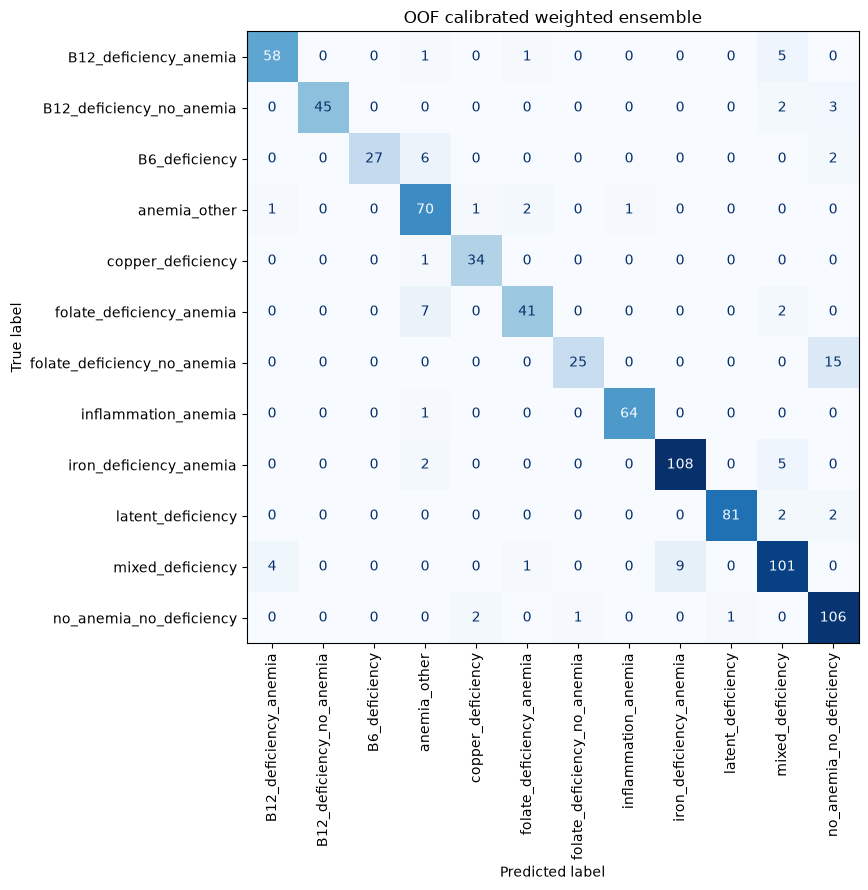

In [19]:
classes = sorted(work["anemia_class"].unique())

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    work["anemia_class"],
    ensemble_class,
    labels=classes,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title("OOF calibrated weighted ensemble")
plt.tight_layout()
plt.show()

## 18. Качество `deficiency_cause`

In [20]:
cause_metrics = pd.DataFrame([{
    "model": "calibrated_weighted_ensemble",
    "macro_f1": f1_score(
        work["deficiency_cause"],
        ensemble_cause,
        average="macro",
        zero_division=0,
    ),
    "accuracy": accuracy_score(
        work["deficiency_cause"],
        ensemble_cause,
    ),
}]).set_index("model")

display(cause_metrics.round(4))

,macro_f1,accuracy
model,,
calibrated_weighted_ensemble,0.8876,0.9036


## 19. Missingness robustness

Проверяем те же три группы пациентов:

- low missingness;
- medium missingness;
- high missingness.

Это важно, потому что на EDA структура пропусков сама по себе несла информацию о классе.

In [24]:
TARGET_COLUMNS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
    "anemia_class",
    "deficiency_cause",
]

FEATURE_COLUMNS = [
    c for c in df.columns
    if c not in TARGET_COLUMNS + ["patient_id"]
]

missing_fraction = (
    work[FEATURE_COLUMNS]
    .isna()
    .mean(axis=1)
)

missing_group = pd.qcut(
    missing_fraction,
    q=3,
    labels=[
        "low_missingness",
        "medium_missingness",
        "high_missingness",
    ],
    duplicates="drop",
)

robustness_rows = []

for group in pd.Series(missing_group).dropna().unique():
    mask = (missing_group == group)

    robustness_rows.append({
        "group": str(group),
        "n": int(mask.sum()),
        "mean_missing_fraction": missing_fraction[mask].mean(),
        "macro_f1": f1_score(
            work.loc[mask, "anemia_class"],
            ensemble_class[mask],
            average="macro",
            zero_division=0,
        ),
        "accuracy": accuracy_score(
            work.loc[mask, "anemia_class"],
            ensemble_class[mask],
        ),
    })

robustness = pd.DataFrame(robustness_rows)
display(
    robustness.sort_values("mean_missing_fraction").round(4)
)

,group,n,mean_missing_fraction,macro_f1,accuracy
2,low_missingness,343,0.2692,0.9364,0.9242
0,medium_missingness,236,0.3763,0.8786,0.9068
1,high_missingness,261,0.4933,0.8718,0.8774



## 20. Что означают клинические правила в продукте

Clinical rules не должны молча «переписывать» ML.

Предлагаем три роли.

### 1. Hard deterministic rule

Только там, где правило действительно однозначно:

```text
Hb + sex -> anemia
```

### 2. Evidence rule

Теперь подтверждённые примеры:

```text
Ret-He < 30.6
+ low ferritin / low serum iron / low TSAT / high TIBC
-> evidence iron deficiency
```

```text
vitamin B12 < 140 pg/mL
-> strong evidence B12 deficiency
```

```text
folate < 4
-> strong evidence folate deficiency

folate 4–8
-> borderline; нужен дополнительный контекст (например homocysteine)
```

Это **не автоматический окончательный диагноз**, а независимый клинический сигнал,
который ансамбль может использовать или проигнорировать.

### 3. Conflict / safety rule

Если ML говорит `iron deficiency`, а железный профиль прямо противоречит ему, система может:

- снизить confidence;
- показать конфликт;
- рекомендовать проверить дополнительные показатели;
- не выдавать уверенный диагноз как факт.

То же будет применяться к B12/folate:

- ML высокий, но подтверждающий marker отсутствует → explanation/conflict;
- marker сильный, а ML низкий → flag для повторной проверки.

### Почему B6/copper пока без hard rule

Отсутствие правила — осознанное решение.

Мы не переносим в код случайный лабораторный reference range и не называем его
«критерием Минздрава», если специализированная рекомендация не задаёт такой cutoff.

В API позже вместе с `prediction` можно будет возвращать:

- `evidence`;
- `conflicts`;
- `source`;
- `rule_strength`;
- `recommended_next_tests`.


# 21. Что делаем дальше

Если ensemble стабильно улучшает или хотя бы сохраняет Macro-F1 при лучшей calibration:

1. фиксируем ensemble;
2. переносим clinical rule config в отдельный модуль проекта;
3. добавляем explanation payload;
4. затем подключаем внешний источник данных;
5. проводим настоящий transfer/generalization test.

Если ensemble ухудшает качество:

- правила не выбрасываем;
- используем их как explanation/conflict layer;
- prediction оставляем за лучшей OOF-моделью.

Это важный принцип:

> Clinical rules должны улучшать надёжность и интерпретируемость, а не обязательно насильно повышать одну метрику.

# 22. Фиксируем ensemble и сохраняем артефакты для expert/explanation layer
На этом этапе ничего не переобучаем и не меняем в алгоритме.
Сохраняем:
- OOF ensemble probabilities;
- OOF binary predictions;
- итоговый anemia_class;
- итоговый deficiency_cause;
- clinical rule scores;
- настройки meta-fold (weights, threshold);
- таблицу calibration;
- итоговые сравнительные метрики.
05_expert_system_explanations.ipynb будет использовать эти файлы как вход и
не будет повторно обучать L1/CatBoost.

In [26]:
def resolve_artifact_root():
    candidates = [
        Path("../artifacts/ensemble"),
        Path("artifacts/ensemble"),
        Path("../../artifacts/ensemble"),
    ]
    for candidate in candidates:
        try:
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
        except Exception:
            pass
    raise RuntimeError("Не удалось создать папку artifacts/ensemble")

ENSEMBLE_ARTIFACT_DIR = resolve_artifact_root()
print("Ensemble artifacts:", ENSEMBLE_ARTIFACT_DIR)

ensemble_oof = pd.DataFrame({
    "patient_id": work["patient_id"].to_numpy(),
    "anemia_class_true": work["anemia_class"].to_numpy(),
    "deficiency_cause_true": work["deficiency_cause"].to_numpy(),
    "anemia_rule": work["anemia_rule_04"].to_numpy(),
    "ensemble_class_pred": np.asarray(ensemble_class),
    "ensemble_cause_pred": np.asarray(ensemble_cause),
})

for target in RULE_TARGETS:
    ensemble_oof[f"{target}__true"] = work[target].astype(int).to_numpy()
    ensemble_oof[f"{target}__probability"] = ensemble_probability[target]
    ensemble_oof[f"{target}__prediction"] = ensemble_prediction[target]
    ensemble_oof[f"{target}__rule_score"] = rule_scores[target].to_numpy(dtype=float)

ensemble_oof.to_csv(
    ENSEMBLE_ARTIFACT_DIR / "ensemble_oof_predictions.csv",
    index=False,
)

meta_settings.to_csv(
    ENSEMBLE_ARTIFACT_DIR / "ensemble_meta_settings.csv",
    index=False,
)

calibration_summary.to_csv(
    ENSEMBLE_ARTIFACT_DIR / "calibration_summary.csv",
    index=False,
)

comparison.to_csv(
    ENSEMBLE_ARTIFACT_DIR / "model_comparison.csv",
)

binary_ensemble_summary.to_csv(
    ENSEMBLE_ARTIFACT_DIR / "binary_ensemble_summary.csv",
    index=False,
)



print("Сохранено:")
for p in sorted(ENSEMBLE_ARTIFACT_DIR.glob("*.csv")):
    print(" -", p.name)


Ensemble artifacts: /home/sinopah/meditron/artifacts/ensemble
Сохранено:
 - binary_ensemble_summary.csv
 - calibration_summary.csv
 - ensemble_meta_settings.csv
 - ensemble_oof_predictions.csv
 - model_comparison.csv
